# Runtime plot

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import plot_basics
import ddb.config

importlib.reload(plot_basics)
importlib.reload(ddb.config)

from ddb.config import Params

Setup directories

In [2]:
input_dir = Path("../in")
output_dir = Path("../out")
results_dir = output_dir / "results"
image_output_dir = results_dir / "images"

image_output_dir.mkdir(exist_ok=True, parents=True)

DDB times

In [3]:
with open(results_dir / "finn_training_time.txt", "r") as file:
    mean_finn_training_time = float(file.read().split(" ")[0].strip())
with open(results_dir / "quantile_computing_time.txt", "r") as file:
    quantile_computing_time = float(file.read().split(" ")[0].strip())
with open(results_dir / "ddb_finns_training_time.txt", "r") as file:
    ddb_finns_training_time = float(file.read().split(" ")[0].strip())
number_finns = Params.n_mixed_quantiles

ddb_runtime = mean_finn_training_time + quantile_computing_time +  ddb_finns_training_time
ddb_runtime_per_sample = mean_finn_training_time + quantile_computing_time + ddb_finns_training_time / number_finns

Comparison

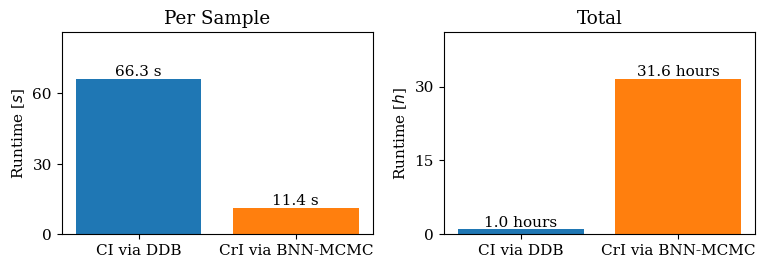

In [4]:
# Data
methods_per_sample = ["CI via DDB", "CrI via BNN-MCMC"]
# runtimes_per_sample = [sum([18.67, 21.43, 24.35, 23.77, 24.71, 28.63, 28.43]), 22.75319 / 2,]
runtimes_per_sample = [ddb_runtime_per_sample, 22.75319 / 2,]

methods_total = methods_per_sample
# runtimes_total = [70 * sum([18.67, 21.43, 24.35, 23.77, 24.71, 28.63, 28.43]) / 60 / 60, 10_000 * 22.75319 / 2 / 60 / 60,]
runtimes_total = [ddb_runtime / 60 / 60, 10_000 * 22.75319 / 2 / 60 / 60,]

# Create a figure and two axes side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(plot_basics.FIGURE_WIDTH * 2.6, 1.5 * plot_basics.FIGURE_HEIGHT))

# Plot for per-sample runtime
colors_per_sample = ["C0", "C1"]
bars1 = ax1.bar(x=methods_per_sample, height=runtimes_per_sample, color=colors_per_sample)
for bar, runtime in zip(bars1, runtimes_per_sample):
    ax1.annotate(
        f"{runtime:.1f} s",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
    )
ax1.set_ylabel("Runtime [$s$]")
# ax1.set_xlabel("Sampling Methods")
ax1.set_ylim(0, max(runtimes_per_sample) * 1.3)
# ax1.grid(axis="x", linestyle="", alpha=0.7)
# ax1.grid(axis="y", linestyle="-", alpha=0.7)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(3))
ax1.set_title("Per Sample")


# Plot for total runtime
colors_total = ["C0", "C1"]
bars2 = ax2.bar(x=methods_total, height=runtimes_total, color=colors_total)
for bar, runtime in zip(bars2, runtimes_total):
    ax2.annotate(
        f"{runtime:.1f} hours",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
    )

ax2.set_ylabel("Runtime [$h$]")
# ax2.set_xlabel("Sampling Methods")
ax2.set_ylim(0, max(runtimes_total) * 1.3)
# ax2.grid(axis="x", linestyle="", alpha=0.7)
# ax2.grid(axis="y", linestyle="-", alpha=0.7)
ax2.yaxis.set_major_locator(ticker.MaxNLocator(3))
ax2.set_title("Total")


plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "runtime_comparison")
plt.show()